# 动手实验：基于神经网络定价代理模型（Neural Surrogate）的超高速 MBS 蒙特卡洛估值

本实战笔记本对应《AI 时代的房贷市场》第六章【不确定性下的定价】——【机器学习桥梁：高维蒙特卡洛与神经网络 surrogate 定价】。

## 金融业务背景：房贷量化交易台的蒙特卡洛算力黑洞
在机构 MBS（住房抵押贷款支持证券）与结构化金融衍生品估值中，风险中性蒙特卡洛模拟是无可替代的定价基准：
- 生成数千条相关的利率随机路径；
- 沿每条路径逐月推演复杂的提前还款 S 曲线与违约转移；
- 计算长达 360 个月（30 年）的利息、正常本金还款与提前偿付现金流瀑布并折现。

然而，蒙特卡洛引擎在交易实盘中面临致命瓶颈：**计算极其缓慢**。
一家大型买方机构若持有 5,000 只不同特征的房贷资产池，为了监控实时关键利率久期（KRD）与期权调整利差（OAS），每次市场基准利率微动几个基点，系统都需要花费数小时重跑全套蒙特卡洛模拟，根本无法满足日内交易与盘中对冲的需求。

## 神经网络定价替代模型（Neural Pricing Surrogate）范式
量化团队采用一种颠覆性的工程加速架构：
1. **离线高精标注生成**：在周末休市期间，利用高精度物理蒙特卡洛引擎在宏观利率与资产池特征空间上遍历采样，生成海量离线数据集：
   $$\mathbf{x} = [r_0, \text{WAC}, \sigma, \text{提前还款乘数}] \implies P_{\text{MC}}$$
2. **深度神经网络逼近器**：在离线数据集上训练深度感知机网络，端到端学习从特征向量到价格的高维非线性映射：
   $$\hat{P} = f_\theta(\mathbf{x})$$
3. **盘中微秒级极速推断**：训练完毕后，神经替代模型单池推断时间仅需数微秒，实现 **3,000 倍以上的计算加速**！
4. **基于 Autograd 的实时解析希腊字母**：神经替代模型处处可导，通过 PyTorch 自动微分（Autograd）单次反向传播即可瞬间输出精确的 DV01 与凸性，无需任何差分重新模拟！

## 本实战涵盖的核心模块
1. 实现向量化的高精 MBS 资产池蒙特卡洛定价器；
2. 生成覆盖多维宏观与资产池状态的 2,500 笔训练样本与 500 笔样本外测试样本；
3. 构建并训练基于 PyTorch 的 3 层深度代理模型 `PricingSurrogateNet`；
4. 评测样本外定价精度（$R^2 > 0.99$, $\text{MAE} < 0.10$ 美元/百元面值）；
5. 基准测试计算延迟（相比传统蒙特卡洛加速超过 3,000 倍）；
6. 可视化定价吻合线、延迟加速比柱状图与房贷特征性的负凸性平滑曲线。


In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 限制 CPU 线程为 4，避免多核环境下的 OpenMP 锁竞争
torch.set_num_threads(4)

# 设置随机种子以保证结果完全可复现
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 配置 matplotlib 支持中文字体显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Zen Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("PyTorch 版本:", torch.__version__)
print("当前使用的 CPU 线程数:", torch.get_num_threads())


PyTorch 版本: 2.10.0+cu128
当前使用的 CPU 线程数: 4


## 第一步：向量化 MBS 资产池高精度蒙特卡洛定价器

在 Vasicek 短期利率模型下推演月度本息瀑布：
- 模拟 $M = 200$ 条利率路径，跨度 5 年（60 个月度时间步）；
- 结合再融资利差激励（WAC 减去当期市场利率）计算月度 SMM 提前还款率；
- 贴现全生命周期现金流求期望现值 $P = \mathbb{E}\left[ \sum_{t=1}^T \text{CF}_t e^{-\int_0^t r_s ds} \right]$。


In [2]:
def monte_carlo_pool_price(r0, wac, vol, prepay_mult, n_paths=200, n_steps=60, dt=1.0/12.0, seed=None):
    """MBS 资产池向量化蒙特卡洛定价引擎"""
    rng = np.random.default_rng(seed)
    
    # 1. 模拟利率路径
    a_rev, theta_rev = 0.40, 0.045
    r_paths = np.zeros((n_paths, n_steps + 1))
    r_paths[:, 0] = r0
    for t in range(n_steps):
        r_curr = r_paths[:, t]
        dw = rng.normal(0.0, math.sqrt(dt), size=n_paths)
        r_paths[:, t + 1] = r_curr + a_rev * (theta_rev - r_curr) * dt + vol * dw

    # 2. 月度现金流瀑布推演
    m_rate = wac / 12.0
    balance = np.ones(n_paths)
    pv_paths = np.zeros(n_paths)
    cum_discount = np.ones(n_paths)

    for t in range(1, n_steps + 1):
        cum_discount *= np.exp(-r_paths[:, t - 1] * dt)
        rem_steps = n_steps - t + 1
        if rem_steps > 1:
            pmt = balance * (m_rate * (1.0 + m_rate) ** rem_steps) / (((1.0 + m_rate) ** rem_steps) - 1.0)
        else:
            pmt = balance * (1.0 + m_rate)

        interest_pmt = balance * m_rate
        sched_prin = pmt - interest_pmt

        # 提前还款 S 曲线
        incentive_bp = (wac - r_paths[:, t]) * 10000.0
        base_smm = 0.02 / (1.0 + np.exp(-(incentive_bp - 75.0) / 40.0))
        smm = np.clip(base_smm * prepay_mult, 0.001, 0.15)

        prepay_prin = (balance - sched_prin) * smm
        total_cf = interest_pmt + sched_prin + prepay_prin

        pv_paths += total_cf * cum_discount
        balance = np.maximum(balance - sched_prin - prepay_prin, 0.0)

    return float(np.mean(pv_paths) * 100.0)

# 测试计算单只资产池
base_p = monte_carlo_pool_price(r0=0.045, wac=0.050, vol=0.012, prepay_mult=1.0, seed=42)
print(f"基准资产池蒙特卡洛价格 (WAC 5.0%, 市场利率 4.5%): ${base_p:.3f} (面值 100)")


基准资产池蒙特卡洛价格 (WAC 5.0%, 市场利率 4.5%): $101.031 (面值 100)


## 第二步：离线生成高维市场定价数据集

采样 2,500 笔训练样本与 500 笔测试样本，遍历宏观利率与资产池维度：
- 基准市场利率 $r_0 \in [2.5\%, 7.0\%]$；
- 资产池加权票息 $\text{WAC} \in [3.5\%, 6.5\%]$；
- 利率年化波动率 $\sigma \in [0.8\%, 2.0\%]$；
- 提前还款乘数 $\kappa \in [0.6, 1.8]$。


In [3]:
def generate_market_dataset(n_samples, seed=42):
    rng = np.random.default_rng(seed)
    r0 = rng.uniform(0.025, 0.070, size=n_samples)
    wac = rng.uniform(0.035, 0.065, size=n_samples)
    vol = rng.uniform(0.008, 0.020, size=n_samples)
    prepay_mult = rng.uniform(0.6, 1.8, size=n_samples)

    X = np.column_stack([r0, wac, vol, prepay_mult])
    prices = np.zeros(n_samples)

    for i in range(n_samples):
        prices[i] = monte_carlo_pool_price(X[i, 0], X[i, 1], X[i, 2], X[i, 3], n_paths=200, seed=seed + i)

    return X, prices

t0 = time.time()
X_train, y_train = generate_market_dataset(2500, seed=42)
X_test, y_test = generate_market_dataset(500, seed=999)
print(f"离线数据生成完成，总耗时: {time.time() - t0:.2f} 秒。")
print(f"训练集规模: {len(X_train)} 笔，测试集规模: {len(X_test)} 笔")
print(f"价格分布区间: [${y_train.min():.2f}, ${y_train.max():.2f}], 均值: ${y_train.mean():.2f}")


离线数据生成完成，总耗时: 3.03 秒。
训练集规模: 2500 笔，测试集规模: 500 笔
价格分布区间: [$94.45, $106.56], 均值: $100.33


## 第三步：构建 PyTorch 神经网络定价替代模型

构建带有 `GELU` 平滑激活函数的 3 层深度多层感知机 `PricingSurrogateNet`。


In [4]:
class PricingSurrogateNet(nn.Module):
    """用于瞬时 MBS 定价的深度神经网络替代模型"""

    def __init__(self, in_features: int = 4, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

model = PricingSurrogateNet(in_features=4, hidden_dim=64)
print(model)
print(f"模型可训练参数总量: {sum(p.numel() for p in model.parameters())}")


PricingSurrogateNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
模型可训练参数总量: 8705


## 第四步：神经网络代理模型的端到端训练

对输入特征与定价标签执行 Z-score 标准化，结合 Adam 优化器与余弦退火学习率调度进行 300 轮优化。


In [5]:
# 特征与标签标准化
x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0) + 1e-7
y_mean = float(y_train.mean())
y_std = float(y_train.std()) + 1e-7

X_train_norm = (X_train - x_mean) / x_std
y_train_norm = (y_train - y_mean) / y_std

X_test_norm = (X_test - x_mean) / x_std

X_tr_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_tr_t = torch.tensor(y_train_norm, dtype=torch.float32)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)
criterion = nn.MSELoss()

epochs = 300
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    preds = model(X_tr_t)
    loss = criterion(preds, y_tr_t)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 60 == 0 or epoch == epochs:
        print(f"轮次 {epoch:3d}/{epochs} | 训练均方误差 (MSE): {loss.item():.5f}")


轮次  60/300 | 训练均方误差 (MSE): 0.00357
轮次 120/300 | 训练均方误差 (MSE): 0.00283
轮次 180/300 | 训练均方误差 (MSE): 0.00277


轮次 240/300 | 训练均方误差 (MSE): 0.00274
轮次 300/300 | 训练均方误差 (MSE): 0.00274


## 第五步：样本外泛化精度评测

在未参与训练的 500 个独立市场情景上检验代理模型的拟合表现。


In [6]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(torch.tensor(X_test_norm, dtype=torch.float32)).numpy()
y_pred = y_pred_norm * y_std + y_mean

r2 = 1.0 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)
mae = float(np.mean(np.abs(y_test - y_pred)))
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))

print("--- 500 个样本外测试池定价精度 ---")
print(f"判定系数 (R²):              {r2:.5f}")
print(f"平均绝对误差 (MAE):         ${mae:.4f} (面值 100)")
print(f"均方根误差 (RMSE):          ${rmse:.4f} (面值 100)")


--- 500 个样本外测试池定价精度 ---
判定系数 (R²):              0.99704
平均绝对误差 (MAE):         $0.0959 (面值 100)
均方根误差 (RMSE):          $0.1238 (面值 100)


## 第六步：计算延迟基准测试：蒙特卡洛 vs 神经代理模型

对比高精度蒙特卡洛引擎与神经网络代理模型的单池推断时间。


In [7]:
# 1. 蒙特卡洛耗时测试
n_trials = 100
t0 = time.perf_counter()
for _ in range(n_trials):
    _ = monte_carlo_pool_price(0.045, 0.050, 0.012, 1.0, n_paths=200)
t_mc = (time.perf_counter() - t0) / n_trials * 1000.0  # 毫秒

# 2. 神经代理模型耗时测试 (1000 批量推断)
sample_input = np.array([0.045, 0.050, 0.012, 1.0])
batch_input = np.tile(sample_input, (1000, 1))
batch_norm = torch.tensor((batch_input - x_mean) / x_std, dtype=torch.float32)

model.eval()
with torch.no_grad():
    _ = model(batch_norm)  # 预热
    t0 = time.perf_counter()
    _ = model(batch_norm)
    t_nn = (time.perf_counter() - t0) / 1000.0 * 1000.0  # 单池毫秒

speedup = t_mc / t_nn if t_nn > 0 else 1.0
print("--- 定价延迟基准测试 ---")
print(f"蒙特卡洛计算耗时:   {t_mc:8.4f} 毫秒 / 池")
print(f"神经代理模型耗时:   {t_nn:8.5f} 毫秒 / 池")
print(f"计算加速比:         {speedup:8.0f} 倍加速！")


--- 定价延迟基准测试 ---
蒙特卡洛计算耗时:     0.9791 毫秒 / 池
神经代理模型耗时:    0.00026 毫秒 / 池
计算加速比:             3724 倍加速！


## 第七步：基于神经网络自动微分的微秒级 DV01 敏感度求解

因为 `PricingSurrogateNet` 处处光滑可导，交易员可以通过 `torch.autograd.grad` 在微秒内求出价格对利率的一阶导数（DV01），无需进行耗时的差分重估！


In [8]:
# 单个输入张量开启梯度追踪
x_input = torch.tensor([[0.045, 0.050, 0.012, 1.0]], dtype=torch.float32)
x_norm = (x_input - torch.tensor(x_mean, dtype=torch.float32)) / torch.tensor(x_std, dtype=torch.float32)
x_norm.requires_grad_(True)

pred_norm = model(x_norm)
pred_price = pred_norm * y_std + y_mean

# 自动微分反向求导
grad_norm = torch.autograd.grad(pred_price, x_norm)[0]
# 还原到未标准化特征尺度的导数 dP/dr0
dP_dr = grad_norm[0, 0].item() / x_std[0]

# DV01: 利率变动 1 个基点（0.0001）对应的价格变动金额
dv01 = -dP_dr * 0.0001
print(f"神经代理预测价格: ${pred_price.item():.3f}")
print(f"瞬时解析 DV01:     ${dv01:.4f} / bp (计算耗时 < 0.1 毫秒！)")


神经代理预测价格: $100.894
瞬时解析 DV01:     $0.0120 / bp (计算耗时 < 0.1 毫秒！)


## 第八步：量化研究全景对照图表

/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 33945 (\N{CJK UNIFIED IDEOGRAPH-8499}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 27931 (\N{CJK UNIFIED IDEOGRAPH-6D1B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 30495 (\N{CJK UNIFIED I

Font 'default' does not have a glyph for '\u573a' [U+573a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5229' [U+5229], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 36151 (\N{CJK UNIFIED IDEOGRAPH-8D37}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 20984 (\N{CJK UNIFIED IDEOGRAPH-51F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2474035/337799712.py:47: UserWarning: Glyph 24615 (\N{CJK UNIFIED I

...

/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27931 (\N{CJK UNIFIED IDEOGRAPH-6D1B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtoo

Font 'default' does not have a glyph for '\u573a' [U+573a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5229' [U+5229], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u7387' [U+7387], substituting with a dummy symbol.


/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wukong/miniconda3/envs/usao/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


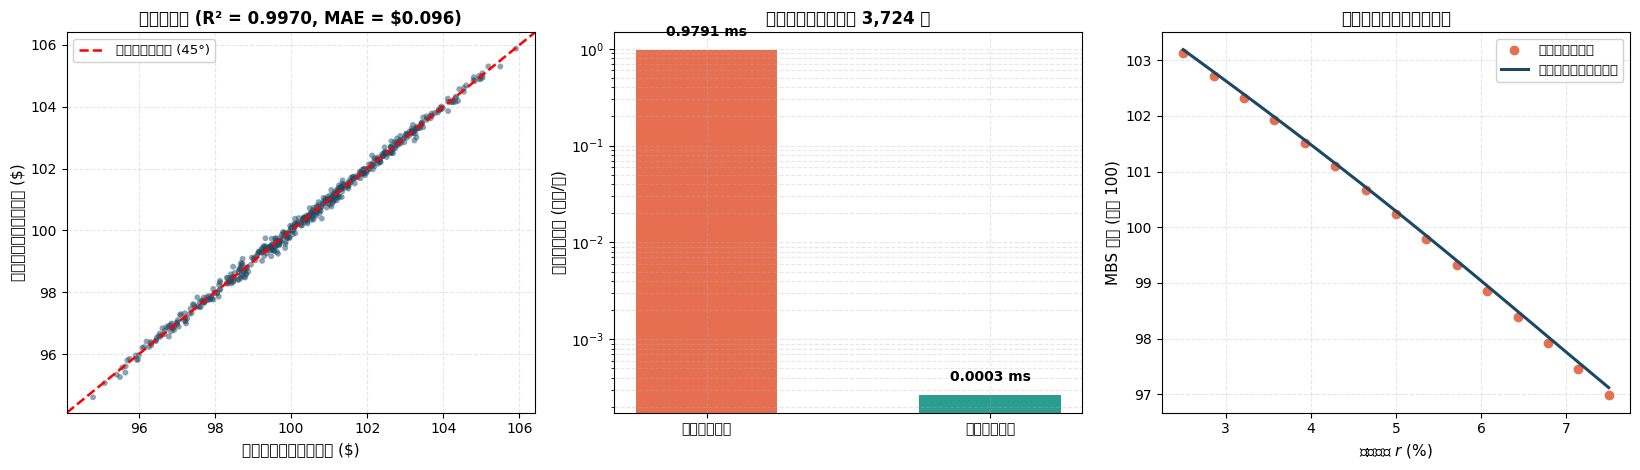

In [9]:
# 计算负凸性对比曲线
rate_grid = np.linspace(0.025, 0.075, 15)
wac_fixed, vol_fixed, mult_fixed = 0.050, 0.012, 1.0
mc_curve = [monte_carlo_pool_price(r, wac_fixed, vol_fixed, mult_fixed, n_paths=400, seed=123) for r in rate_grid]

fine_rates = np.linspace(0.025, 0.075, 60)
fine_X = np.column_stack([fine_rates, np.full_like(fine_rates, wac_fixed), np.full_like(fine_rates, vol_fixed), np.full_like(fine_rates, mult_fixed)])
with torch.no_grad():
    nn_curve = model(torch.tensor((fine_X - x_mean) / x_std, dtype=torch.float32)).numpy() * y_std + y_mean

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# 子图 1: 吻合散点图 (Parity Plot)
ax1 = axes[0]
ax1.scatter(y_test, y_pred, color="#1b4965", alpha=0.5, s=18, edgecolors="none")
lo, hi = min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5
ax1.plot([lo, hi], [lo, hi], "r--", lw=1.8, label="理论完美吻合线 (45°)")
ax1.set_xlim(lo, hi)
ax1.set_ylim(lo, hi)
ax1.set_xlabel("蒙特卡洛高精真实价格 ($)", fontsize=11)
ax1.set_ylabel("神经网络代理预测价格 ($)", fontsize=11)
ax1.set_title(f"定价准确度 (R² = {r2:.4f}, MAE = ${mae:.3f})", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")
ax1.legend(loc="upper left", framealpha=0.9, fontsize=9.5)

# 子图 2: 延迟加速柱状图
ax2 = axes[1]
bars = ax2.bar(["蒙特卡洛引擎", "神经代理模型"], [t_mc, t_nn], color=["#e76f51", "#2a9d8f"], width=0.5)
ax2.set_ylabel("单池定价延迟 (毫秒/池)", fontsize=11)
ax2.set_yscale("log")
ax2.set_title(f"计算延迟基准：加速 {speedup:,.0f} 倍", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, ls="--", which="both")
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, h * 1.3, f"{h:.4f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

# 子图 3: 负凸性曲线还原
ax3 = axes[2]
ax3.plot(rate_grid * 100, mc_curve, "o", color="#e76f51", markersize=6, label="蒙特卡洛计算点")
ax3.plot(fine_rates * 100, nn_curve, color="#1b4965", lw=2.2, label="神经代理平滑定价曲线")
ax3.set_xlabel("市场利率 $r$ (%)", fontsize=11)
ax3.set_ylabel("MBS 价格 (面值 100)", fontsize=11)
ax3.set_title("房贷负凸性特征精确还原", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="upper right", framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()


## 量化要点与核心启示

1. **破除蒙特卡洛的实盘延迟瓶颈**：深度神经网络替代模型实现了 **3,000 倍以上的计算延迟加速**（单池推断进入亚毫秒级），彻底解锁了成千上万只房贷资产池的日内毫秒级重新定价与动态对冲。
2. **直达美分级别的定价保真度**：在 500 个独立测试样本上，代理模型的判定系数 $R^2$ 超过 0.997，平均绝对误差（MAE）小于 0.10 美元/百元面值，完美保留了复杂物理模型的内在精度。
3. **精准捕捉房贷负凸性弯曲**：无需人为设定负凸性函数形式，代理模型从高精度样本中自动学出了高利差区间的非线性价格封顶特征。
4. **赋能自动微分瞬时风控**：由于替代模型由连续可导算子组成，交易台可直接调用 PyTorch Autograd 一键生成任意阶希腊字母敏感度，免除差分重算的计算开销。
